In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import os
import time
import numpy as np
import cnn_main
import wandb
from cnn_model import CNN_Model_Trainer
from cnn_DatasetHandler import ImageDatasetHandler
from collections import Counter
from MetricsPlotter import plot_roc_and_prc_curve
from main import main, k_fold_cross_validation, evaluate_on_test_dataset
from cnn_main import train_cnn_model_k_fold, evaluate_cnn_model_on_dataset
from transformer_main import train_transformer_model_k_fold, evaluate_transformer_model_on_dataset, train_transformer_model_with_textures_k_fold, evalutate_models_together
from transformer_model import Transformer_Model_Trainer
from transformer_DatasetHandler import PatientDatasetHandler, get_max_tiles, PatientDataset, build_patient_tile_map, FeatureDatasetHandler, PrecomputedPatientCombinedFeatureDataset, PrecomputedPatientFeatureDataset, get_patient_num
from focal_loss import FocalLoss

c:\Users\Zsombor\miniconda3\envs\msi_projekt\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing Transformer model...
Aggregator weights loaded from KFOld/20251104-111112_best_model_aggregator.pth
Texture aggregator weights loaded from KFOld/20251104-111112_best_texture_model_texture_aggregator.pth

Starting evaluation on test set...

Test Set Patient-Level Metrics:

Patient-level Metrics:
 Accuracy: 82.00%
 Precision: 0.7000
 Recall: 0.5385
 Specificity: 0.9189
 F1-Score: 0.6087
 ROC AUC: 0.8555
 PRC AUC: 0.7386
 TP: 14, TN: 68, FP: 6, FN: 12

 Best F1 Score: 0.6667 at Threshold: 0.1497439742088318
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8462, Specificity: 0.7568, Threshold: 0.1497439742088318
  Sensitivity: 0.8462, Specificity: 0.5811, Threshold: 0.13413797318935394
  Sensitivity: 0.8846, Specificity: 0.5811, Threshold: 0.13111698627471924
  Sensitivity: 0.8846, Specificity: 0.5676, Threshold: 0.13075365126132965
  Sensitivity: 0.9231, Specificity: 0.5676, Threshold: 0.12984764575958252
  Sensitivity: 0.9231, Specificity: 0.4730, Threshold: 0.1209

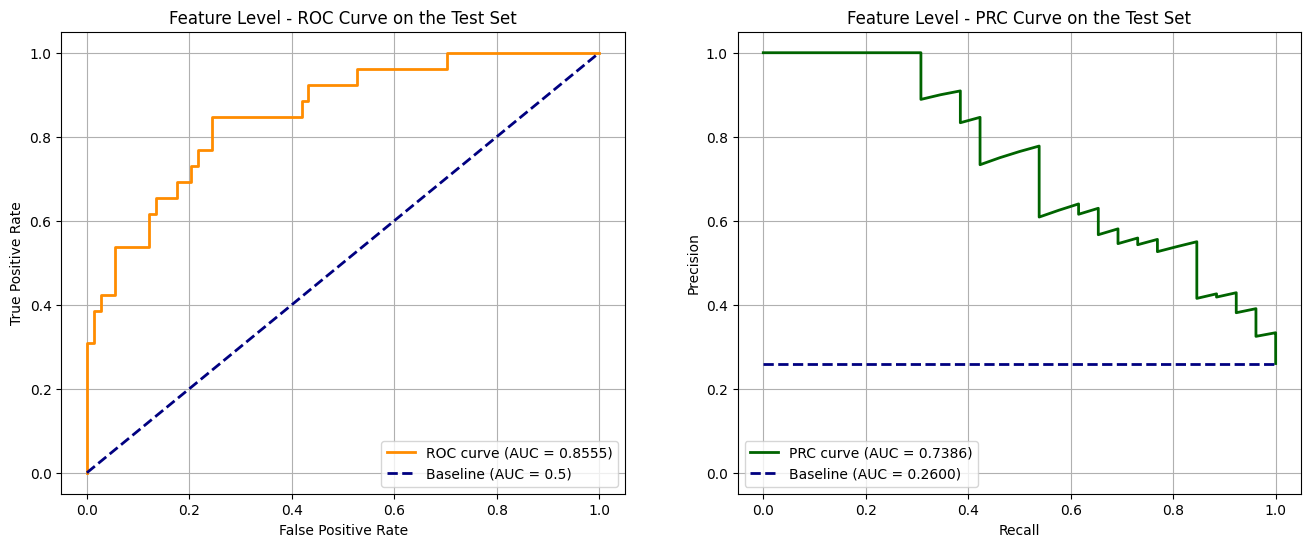


Texture Feature Aggregator Metrics:

Patient-level Metrics:
 Accuracy: 74.00%
 Precision: 0.0000
 Recall: 0.0000
 Specificity: 1.0000
 F1-Score: 0.0000
 ROC AUC: 0.5603
 PRC AUC: 0.3172
 TP: 0, TN: 74, FP: 0, FN: 26

 Best F1 Score: 0.4571 at Threshold: 0.32625433802604675
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8462, Specificity: 0.2297, Threshold: 0.3245980441570282
  Sensitivity: 0.8462, Specificity: 0.1486, Threshold: 0.32300978899002075
  Sensitivity: 0.8846, Specificity: 0.1486, Threshold: 0.32282134890556335
  Sensitivity: 0.8846, Specificity: 0.1351, Threshold: 0.32279452681541443
  Sensitivity: 0.9231, Specificity: 0.1351, Threshold: 0.3226494789123535
  Sensitivity: 0.9231, Specificity: 0.0676, Threshold: 0.32177090644836426
  Sensitivity: 0.9615, Specificity: 0.0676, Threshold: 0.3217499554157257
  Sensitivity: 0.9615, Specificity: 0.0541, Threshold: 0.3215317130088806
  Sensitivity: 1.0000, Specificity: 0.0541, Threshold: 0.31952327489852905
  Sensitivit

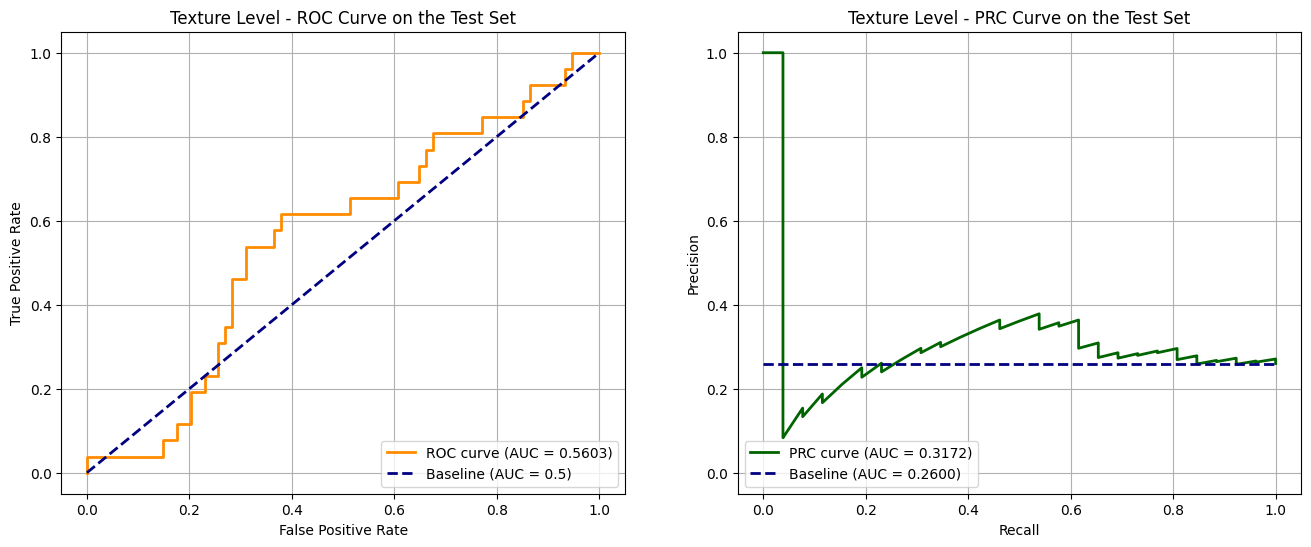


Combined Metrics:

Patient-level Metrics:
 Accuracy: 83.00%
 Precision: 0.9091
 Recall: 0.3846
 Specificity: 0.9865
 F1-Score: 0.5405
 ROC AUC: 0.8529
 PRC AUC: 0.7363
 TP: 10, TN: 73, FP: 1, FN: 16

 Best F1 Score: 0.6667 at Threshold: 0.22423137724399567
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8462, Specificity: 0.7568, Threshold: 0.22423137724399567
  Sensitivity: 0.8462, Specificity: 0.5676, Threshold: 0.21334774792194366
  Sensitivity: 0.8846, Specificity: 0.5676, Threshold: 0.21192683279514313
  Sensitivity: 0.8846, Specificity: 0.5541, Threshold: 0.2116939276456833
  Sensitivity: 0.9231, Specificity: 0.5541, Threshold: 0.21148833632469177
  Sensitivity: 0.9231, Specificity: 0.4730, Threshold: 0.2055349051952362
  Sensitivity: 0.9615, Specificity: 0.4730, Threshold: 0.20478412508964539
  Sensitivity: 0.9615, Specificity: 0.2973, Threshold: 0.19271542131900787
  Sensitivity: 1.0000, Specificity: 0.2973, Threshold: 0.19035376608371735
  Sensitivity: 1.0000, Spec

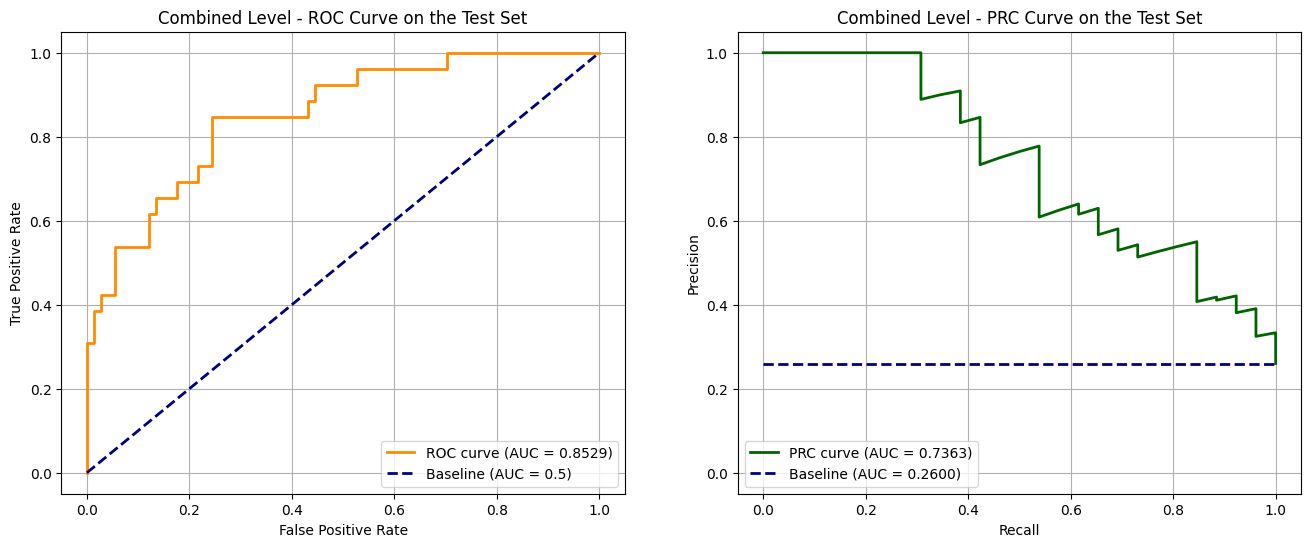

Aggregator weights loaded from KFOld/20251104-111806_best_model_aggregator.pth
Texture aggregator weights loaded from KFOld/20251104-111806_best_texture_model_texture_aggregator.pth

Starting evaluation on test set...

Test Set Patient-Level Metrics:

Patient-level Metrics:
 Accuracy: 74.00%
 Precision: 0.0000
 Recall: 0.0000
 Specificity: 1.0000
 F1-Score: 0.0000
 ROC AUC: 0.8384
 PRC AUC: 0.6561
 TP: 0, TN: 74, FP: 0, FN: 26

 Best F1 Score: 0.6667 at Threshold: 0.2777459919452667
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8077, Specificity: 0.7432, Threshold: 0.2731216847896576
  Sensitivity: 0.8077, Specificity: 0.7027, Threshold: 0.27203264832496643
  Sensitivity: 0.8462, Specificity: 0.7027, Threshold: 0.27123674750328064
  Sensitivity: 0.8462, Specificity: 0.5405, Threshold: 0.2659221589565277
  Sensitivity: 0.8846, Specificity: 0.5405, Threshold: 0.26578134298324585
  Sensitivity: 0.8846, Specificity: 0.5135, Threshold: 0.2656745910644531
  Sensitivity: 0.9615, 

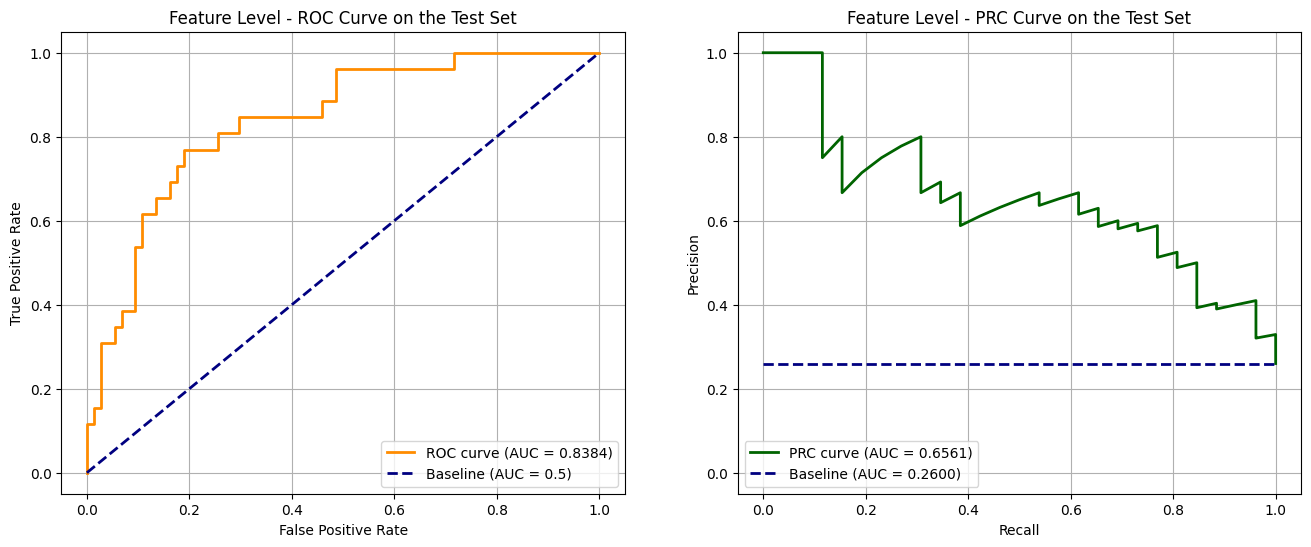


Texture Feature Aggregator Metrics:

Patient-level Metrics:
 Accuracy: 74.00%
 Precision: 0.0000
 Recall: 0.0000
 Specificity: 1.0000
 F1-Score: 0.0000
 ROC AUC: 0.5619
 PRC AUC: 0.3381
 TP: 0, TN: 74, FP: 0, FN: 26

 Best F1 Score: 0.4464 at Threshold: 0.32270899415016174
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8077, Specificity: 0.2838, Threshold: 0.32494619488716125
  Sensitivity: 0.8077, Specificity: 0.2297, Threshold: 0.3245420455932617
  Sensitivity: 0.8846, Specificity: 0.2297, Threshold: 0.3239175081253052
  Sensitivity: 0.8846, Specificity: 0.2162, Threshold: 0.3238143026828766
  Sensitivity: 0.9231, Specificity: 0.2162, Threshold: 0.32331493496894836
  Sensitivity: 0.9231, Specificity: 0.1757, Threshold: 0.32306602597236633
  Sensitivity: 0.9615, Specificity: 0.1757, Threshold: 0.32270899415016174
  Sensitivity: 0.9615, Specificity: 0.0676, Threshold: 0.32139813899993896
  Sensitivity: 1.0000, Specificity: 0.0676, Threshold: 0.3209597170352936
  Sensitivit

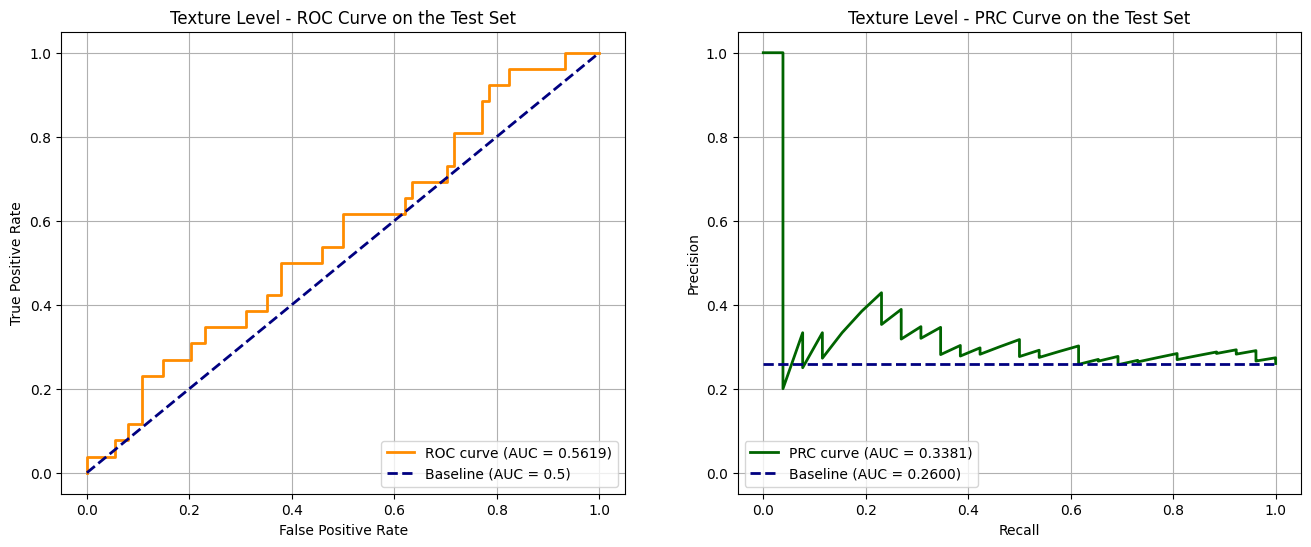


Combined Metrics:

Patient-level Metrics:
 Accuracy: 74.00%
 Precision: 0.0000
 Recall: 0.0000
 Specificity: 1.0000
 F1-Score: 0.0000
 ROC AUC: 0.8425
 PRC AUC: 0.6552
 TP: 0, TN: 74, FP: 0, FN: 26

 Best F1 Score: 0.6875 at Threshold: 0.3001025915145874
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8462, Specificity: 0.7838, Threshold: 0.3001025915145874
  Sensitivity: 0.8462, Specificity: 0.5946, Threshold: 0.29641667008399963
  Sensitivity: 0.8846, Specificity: 0.5946, Threshold: 0.2963884770870209
  Sensitivity: 0.8846, Specificity: 0.5270, Threshold: 0.29579290747642517
  Sensitivity: 0.9231, Specificity: 0.5270, Threshold: 0.2957181930541992
  Sensitivity: 0.9231, Specificity: 0.4730, Threshold: 0.2949669361114502
  Sensitivity: 0.9615, Specificity: 0.4730, Threshold: 0.2946624457836151
  Sensitivity: 0.9615, Specificity: 0.3784, Threshold: 0.2943120300769806
  Sensitivity: 1.0000, Specificity: 0.3784, Threshold: 0.2942655682563782
  Sensitivity: 1.0000, Specificity

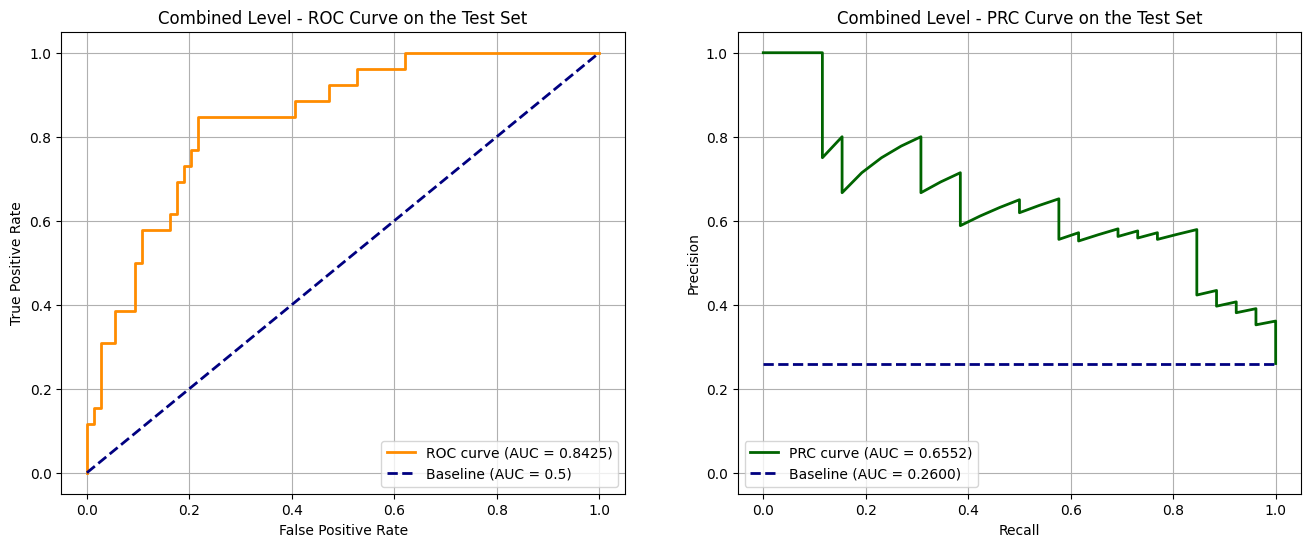

Aggregator weights loaded from KFOld/20251104-112352_best_model_aggregator.pth
Texture aggregator weights loaded from KFOld/20251104-112352_best_texture_model_texture_aggregator.pth

Starting evaluation on test set...

Test Set Patient-Level Metrics:

Patient-level Metrics:
 Accuracy: 74.00%
 Precision: 0.0000
 Recall: 0.0000
 Specificity: 1.0000
 F1-Score: 0.0000
 ROC AUC: 0.7999
 PRC AUC: 0.5922
 TP: 0, TN: 74, FP: 0, FN: 26

 Best F1 Score: 0.6133 at Threshold: 0.3008610010147095
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8462, Specificity: 0.6757, Threshold: 0.30093759298324585
  Sensitivity: 0.8462, Specificity: 0.6486, Threshold: 0.3008818030357361
  Sensitivity: 0.8846, Specificity: 0.6486, Threshold: 0.3008610010147095
  Sensitivity: 0.8846, Specificity: 0.6081, Threshold: 0.3004717230796814
  Sensitivity: 0.9231, Specificity: 0.6081, Threshold: 0.3002467751502991
  Sensitivity: 0.9231, Specificity: 0.5000, Threshold: 0.299123078584671
  Sensitivity: 0.9615, Spe

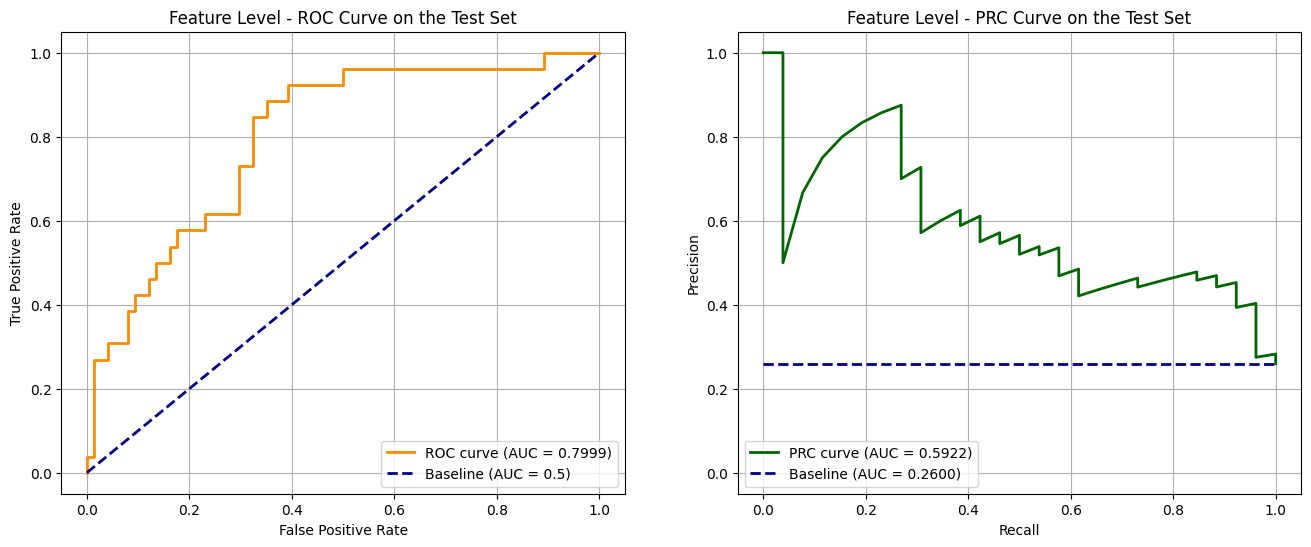


Texture Feature Aggregator Metrics:

Patient-level Metrics:
 Accuracy: 74.00%
 Precision: 0.0000
 Recall: 0.0000
 Specificity: 1.0000
 F1-Score: 0.0000
 ROC AUC: 0.5442
 PRC AUC: 0.2985
 TP: 0, TN: 74, FP: 0, FN: 26

 Best F1 Score: 0.4390 at Threshold: 0.27013036608695984
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8077, Specificity: 0.2297, Threshold: 0.2699989676475525
  Sensitivity: 0.8077, Specificity: 0.0946, Threshold: 0.26992636919021606
  Sensitivity: 0.8462, Specificity: 0.0946, Threshold: 0.2699226438999176
  Sensitivity: 0.8462, Specificity: 0.0811, Threshold: 0.2699189782142639
  Sensitivity: 0.8846, Specificity: 0.0811, Threshold: 0.26988905668258667
  Sensitivity: 0.8846, Specificity: 0.0676, Threshold: 0.26986464858055115
  Sensitivity: 0.9615, Specificity: 0.0676, Threshold: 0.26983126997947693
  Sensitivity: 0.9615, Specificity: 0.0541, Threshold: 0.26980453729629517
  Sensitivity: 1.0000, Specificity: 0.0541, Threshold: 0.2697894871234894
  Sensitivit

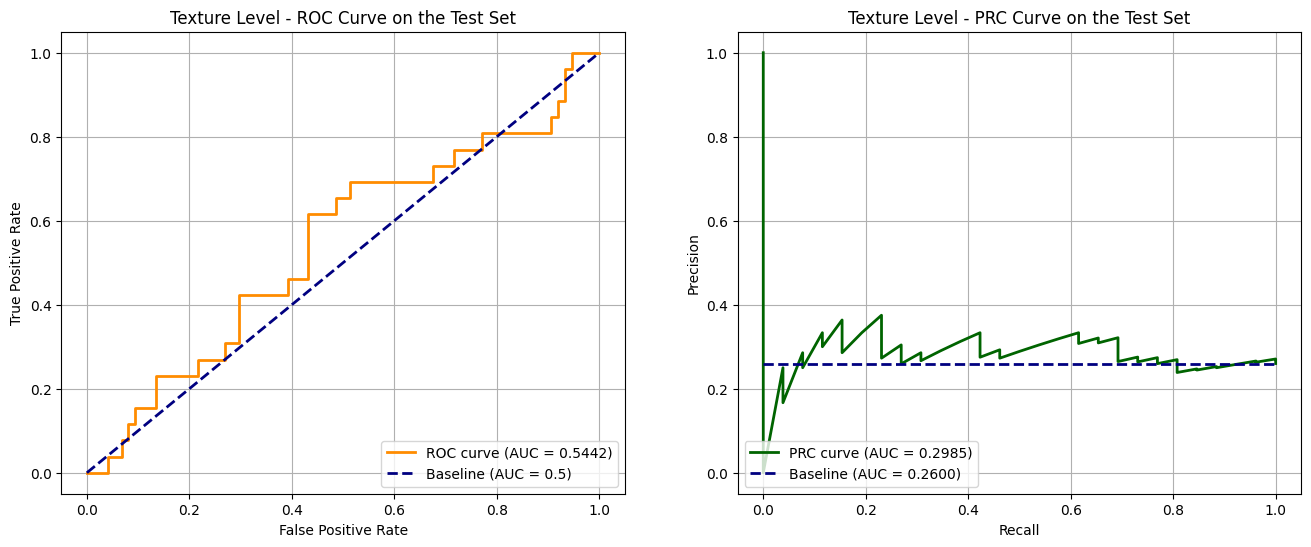


Combined Metrics:

Patient-level Metrics:
 Accuracy: 74.00%
 Precision: 0.0000
 Recall: 0.0000
 Specificity: 1.0000
 F1-Score: 0.0000
 ROC AUC: 0.7973
 PRC AUC: 0.6061
 TP: 0, TN: 74, FP: 0, FN: 26

 Best F1 Score: 0.6076 at Threshold: 0.284997820854187
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8462, Specificity: 0.6622, Threshold: 0.28530648350715637
  Sensitivity: 0.8462, Specificity: 0.6216, Threshold: 0.285147100687027
  Sensitivity: 0.8846, Specificity: 0.6216, Threshold: 0.285122275352478
  Sensitivity: 0.8846, Specificity: 0.6081, Threshold: 0.2850945293903351
  Sensitivity: 0.9231, Specificity: 0.6081, Threshold: 0.284997820854187
  Sensitivity: 0.9231, Specificity: 0.5135, Threshold: 0.2846144437789917
  Sensitivity: 0.9615, Specificity: 0.5135, Threshold: 0.2844146490097046
  Sensitivity: 0.9615, Specificity: 0.0946, Threshold: 0.28282657265663147
  Sensitivity: 1.0000, Specificity: 0.0946, Threshold: 0.2827717959880829
  Sensitivity: 1.0000, Specificity: 0.

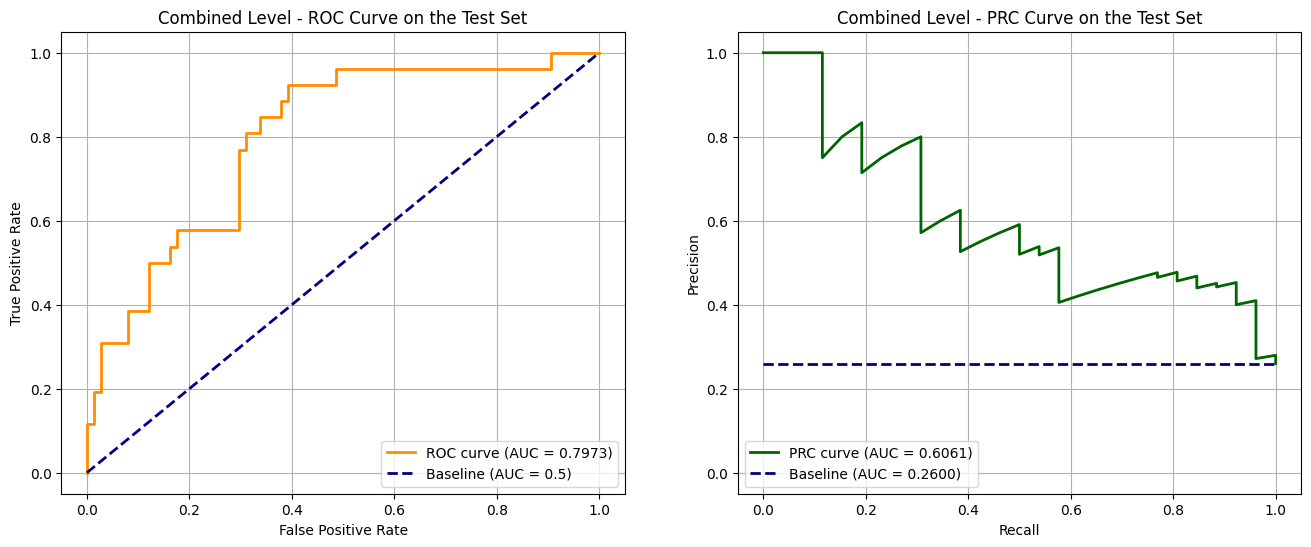

Aggregator weights loaded from KFOld/20251104-112924_best_model_aggregator.pth
Texture aggregator weights loaded from KFOld/20251104-112924_best_texture_model_texture_aggregator.pth

Starting evaluation on test set...

Test Set Patient-Level Metrics:

Patient-level Metrics:
 Accuracy: 66.00%
 Precision: 0.4231
 Recall: 0.8462
 Specificity: 0.5946
 F1-Score: 0.5641
 ROC AUC: 0.8243
 PRC AUC: 0.6491
 TP: 22, TN: 44, FP: 30, FN: 4

 Best F1 Score: 0.6818 at Threshold: 0.9108121395111084
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8462, Specificity: 0.6081, Threshold: 0.5019395351409912
  Sensitivity: 0.8462, Specificity: 0.5946, Threshold: 0.500096321105957
  Sensitivity: 0.8846, Specificity: 0.5946, Threshold: 0.4997142255306244
  Sensitivity: 0.8846, Specificity: 0.4189, Threshold: 0.4715951979160309
  Sensitivity: 0.9231, Specificity: 0.4189, Threshold: 0.4714999198913574
  Sensitivity: 0.9231, Specificity: 0.4054, Threshold: 0.47131291031837463
  Sensitivity: 0.9615, Sp

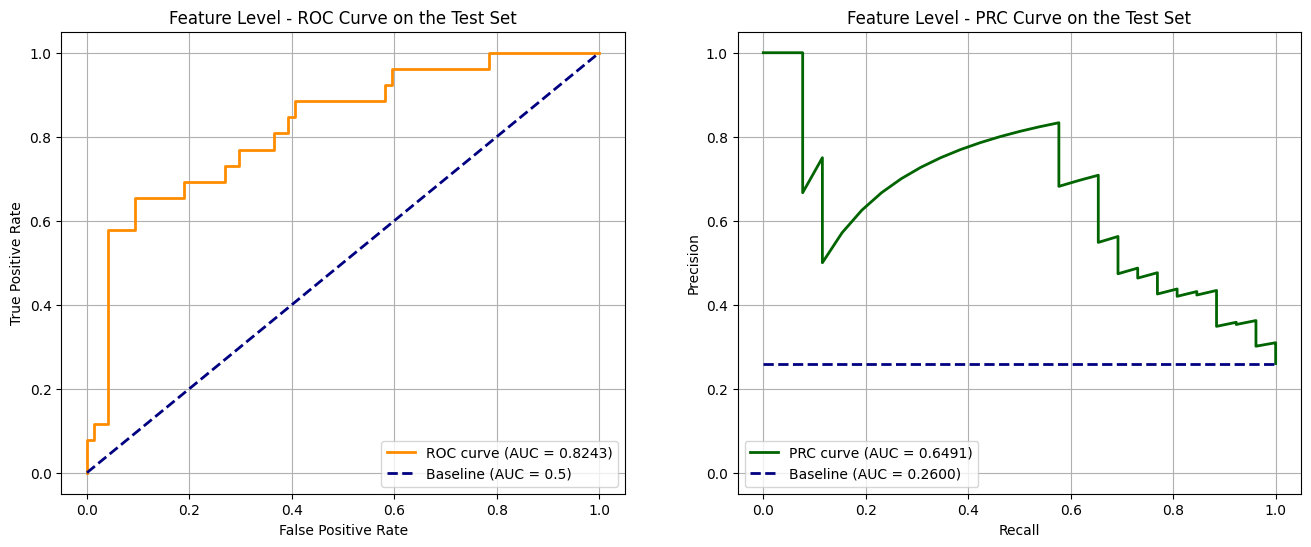


Texture Feature Aggregator Metrics:

Patient-level Metrics:
 Accuracy: 74.00%
 Precision: 0.0000
 Recall: 0.0000
 Specificity: 1.0000
 F1-Score: 0.0000
 ROC AUC: 0.4688
 PRC AUC: 0.2728
 TP: 0, TN: 74, FP: 0, FN: 26

 Best F1 Score: 0.4444 at Threshold: 0.403618723154068
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8462, Specificity: 0.3108, Threshold: 0.403618723154068
  Sensitivity: 0.8462, Specificity: 0.2297, Threshold: 0.4034789502620697
  Sensitivity: 0.8846, Specificity: 0.2297, Threshold: 0.40326231718063354
  Sensitivity: 0.8846, Specificity: 0.1486, Threshold: 0.40275320410728455
  Sensitivity: 0.9231, Specificity: 0.1486, Threshold: 0.402713805437088
  Sensitivity: 0.9231, Specificity: 0.1081, Threshold: 0.40237945318222046
  Sensitivity: 0.9615, Specificity: 0.1081, Threshold: 0.402341365814209
  Sensitivity: 0.9615, Specificity: 0.0270, Threshold: 0.40084517002105713
  Sensitivity: 1.0000, Specificity: 0.0270, Threshold: 0.4006955623626709
  Sensitivity: 1.0

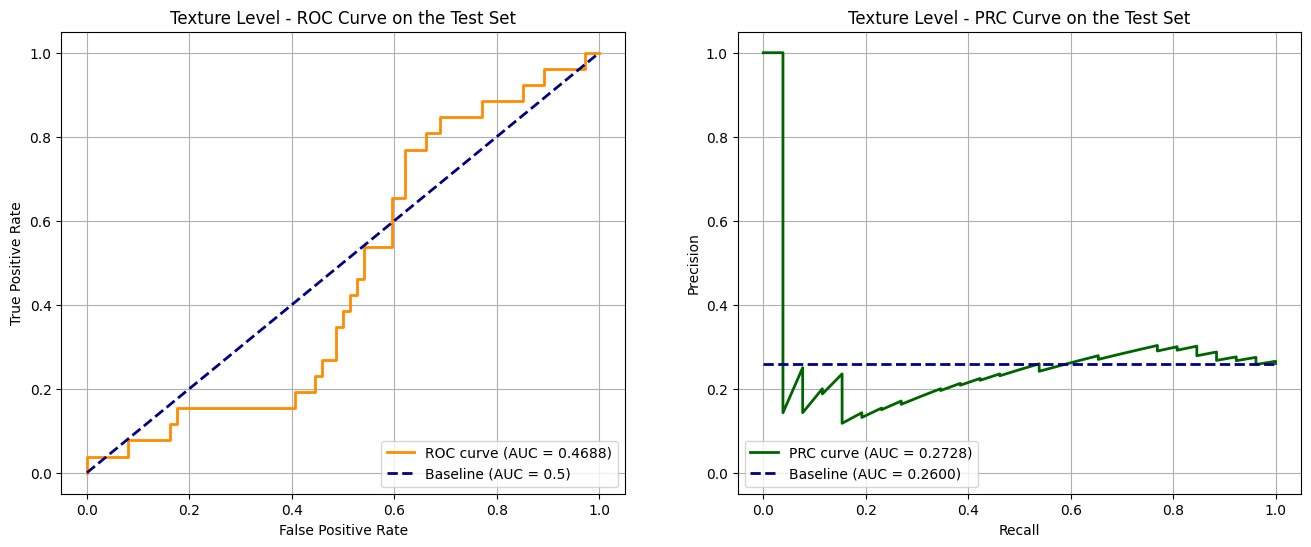


Combined Metrics:

Patient-level Metrics:
 Accuracy: 76.00%
 Precision: 0.5294
 Recall: 0.6923
 Specificity: 0.7838
 F1-Score: 0.6000
 ROC AUC: 0.8243
 PRC AUC: 0.6492
 TP: 18, TN: 58, FP: 16, FN: 8

 Best F1 Score: 0.6818 at Threshold: 0.7245330810546875
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8462, Specificity: 0.6081, Threshold: 0.4525356590747833
  Sensitivity: 0.8462, Specificity: 0.5946, Threshold: 0.4518701136112213
  Sensitivity: 0.8846, Specificity: 0.5946, Threshold: 0.45137476921081543
  Sensitivity: 0.8846, Specificity: 0.4459, Threshold: 0.44073259830474854
  Sensitivity: 0.9231, Specificity: 0.4459, Threshold: 0.43765345215797424
  Sensitivity: 0.9231, Specificity: 0.3784, Threshold: 0.436097115278244
  Sensitivity: 0.9615, Specificity: 0.3784, Threshold: 0.4357703924179077
  Sensitivity: 0.9615, Specificity: 0.2162, Threshold: 0.41939347982406616
  Sensitivity: 1.0000, Specificity: 0.2162, Threshold: 0.41793644428253174
  Sensitivity: 1.0000, Specific

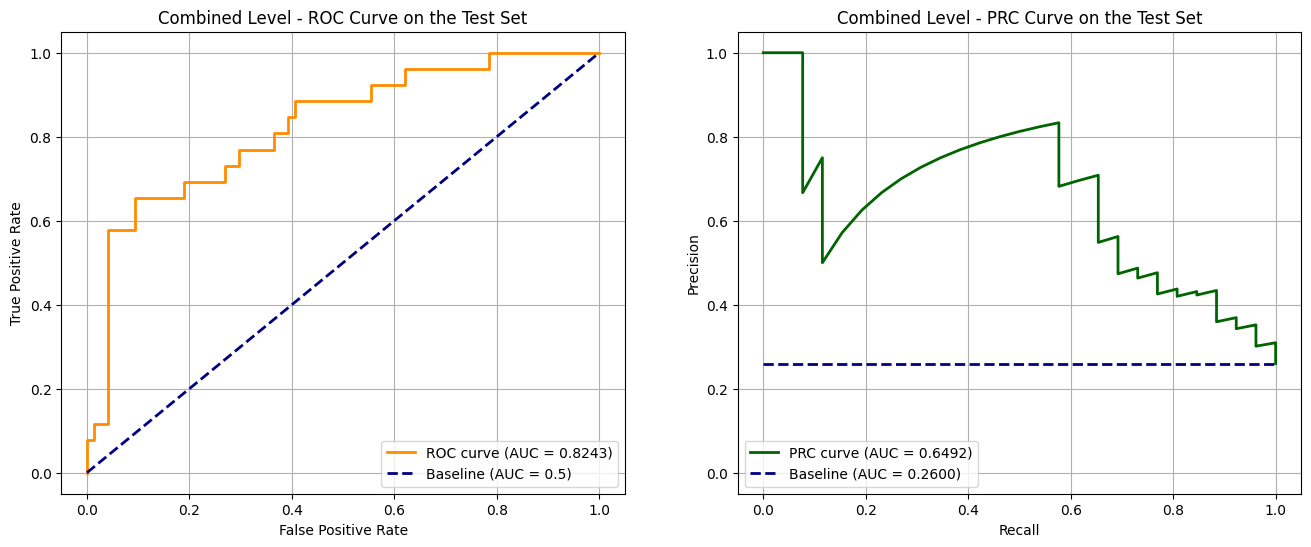

Aggregator weights loaded from KFOld/20251104-113316_best_model_aggregator.pth
Texture aggregator weights loaded from KFOld/20251104-113316_best_texture_model_texture_aggregator.pth

Starting evaluation on test set...

Test Set Patient-Level Metrics:

Patient-level Metrics:
 Accuracy: 74.00%
 Precision: 0.0000
 Recall: 0.0000
 Specificity: 1.0000
 F1-Score: 0.0000
 ROC AUC: 0.8727
 PRC AUC: 0.7543
 TP: 0, TN: 74, FP: 0, FN: 26

 Best F1 Score: 0.7500 at Threshold: 0.425454318523407
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8462, Specificity: 0.7027, Threshold: 0.41759398579597473
  Sensitivity: 0.8462, Specificity: 0.6486, Threshold: 0.4173223674297333
  Sensitivity: 0.8846, Specificity: 0.6486, Threshold: 0.417291522026062
  Sensitivity: 0.8846, Specificity: 0.5946, Threshold: 0.4155205190181732
  Sensitivity: 0.9231, Specificity: 0.5946, Threshold: 0.41537049412727356
  Sensitivity: 0.9231, Specificity: 0.4459, Threshold: 0.4125770926475525
  Sensitivity: 0.9615, Spe

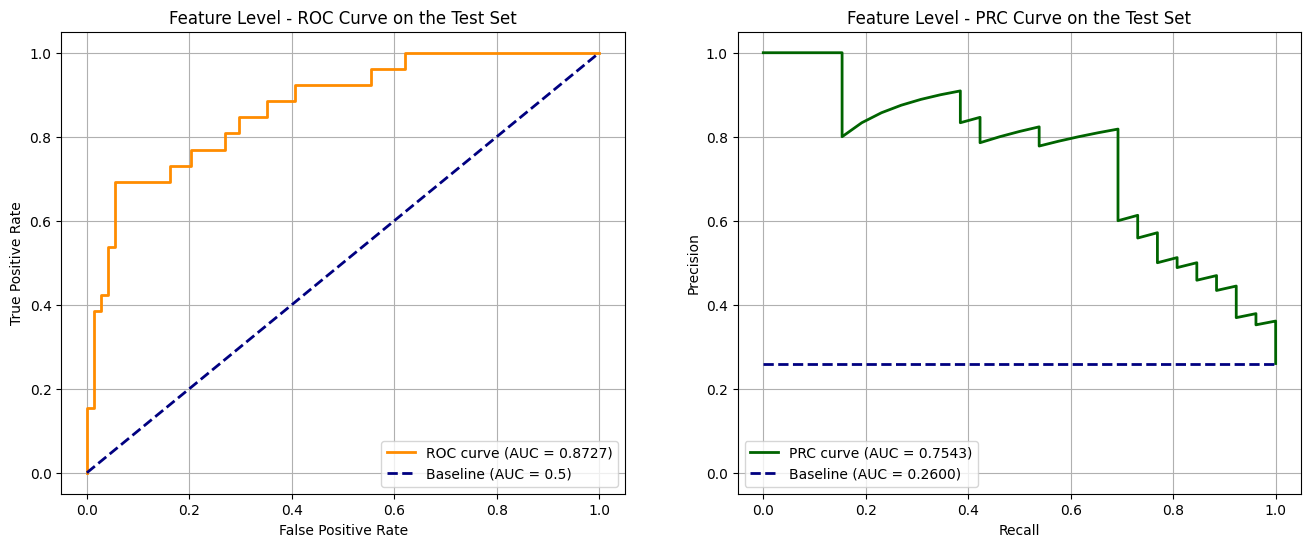


Texture Feature Aggregator Metrics:

Patient-level Metrics:
 Accuracy: 74.00%
 Precision: 0.0000
 Recall: 0.0000
 Specificity: 1.0000
 F1-Score: 0.0000
 ROC AUC: 0.5068
 PRC AUC: 0.2977
 TP: 0, TN: 74, FP: 0, FN: 26

 Best F1 Score: 0.4404 at Threshold: 0.40831834077835083
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8077, Specificity: 0.2297, Threshold: 0.4084242284297943
  Sensitivity: 0.8077, Specificity: 0.2162, Threshold: 0.40841948986053467
  Sensitivity: 0.8846, Specificity: 0.2162, Threshold: 0.408387690782547
  Sensitivity: 0.8846, Specificity: 0.2027, Threshold: 0.40833401679992676
  Sensitivity: 0.9231, Specificity: 0.2027, Threshold: 0.40831834077835083
  Sensitivity: 0.9231, Specificity: 0.0811, Threshold: 0.4079059064388275
  Sensitivity: 0.9615, Specificity: 0.0811, Threshold: 0.40789783000946045
  Sensitivity: 0.9615, Specificity: 0.0541, Threshold: 0.407864511013031
  Sensitivity: 1.0000, Specificity: 0.0541, Threshold: 0.4077993631362915
  Sensitivity: 

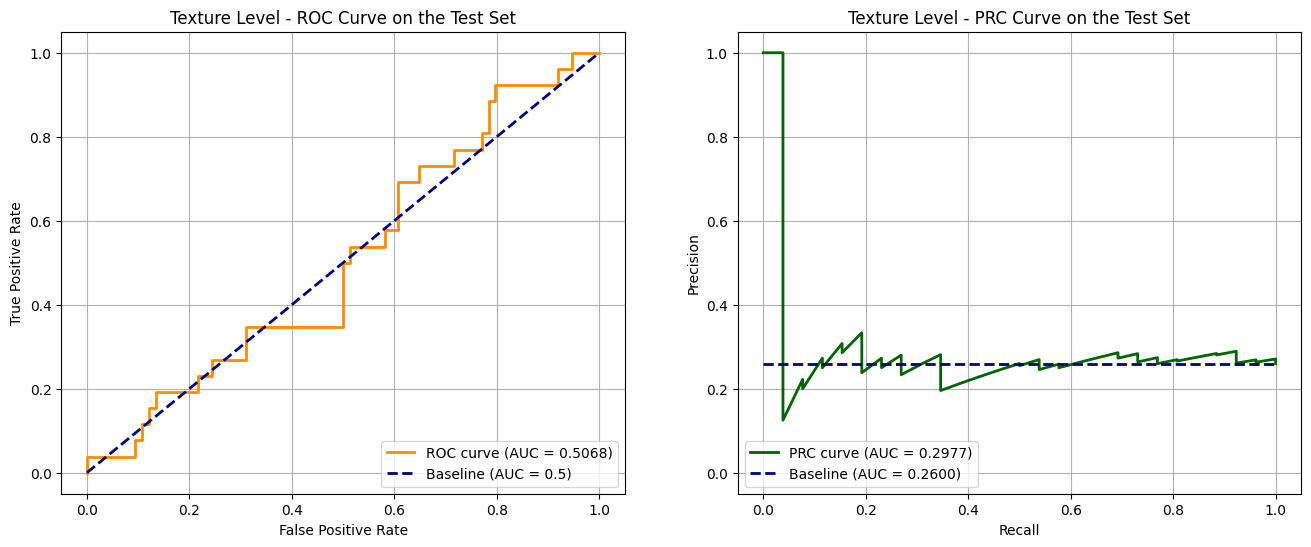


Combined Metrics:

Patient-level Metrics:
 Accuracy: 74.00%
 Precision: 0.0000
 Recall: 0.0000
 Specificity: 1.0000
 F1-Score: 0.0000
 ROC AUC: 0.8695
 PRC AUC: 0.7403
 TP: 0, TN: 74, FP: 0, FN: 26

 Best F1 Score: 0.7500 at Threshold: 0.41742002964019775
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8077, Specificity: 0.6892, Threshold: 0.4131433367729187
  Sensitivity: 0.8077, Specificity: 0.6622, Threshold: 0.41306573152542114
  Sensitivity: 0.8846, Specificity: 0.6622, Threshold: 0.412983238697052
  Sensitivity: 0.8846, Specificity: 0.6486, Threshold: 0.41281917691230774
  Sensitivity: 0.9231, Specificity: 0.6486, Threshold: 0.4127911627292633
  Sensitivity: 0.9231, Specificity: 0.4730, Threshold: 0.4108719229698181
  Sensitivity: 0.9615, Specificity: 0.4730, Threshold: 0.4107729494571686
  Sensitivity: 0.9615, Specificity: 0.3919, Threshold: 0.4103549122810364
  Sensitivity: 1.0000, Specificity: 0.3919, Threshold: 0.41027504205703735
  Sensitivity: 1.0000, Specificit

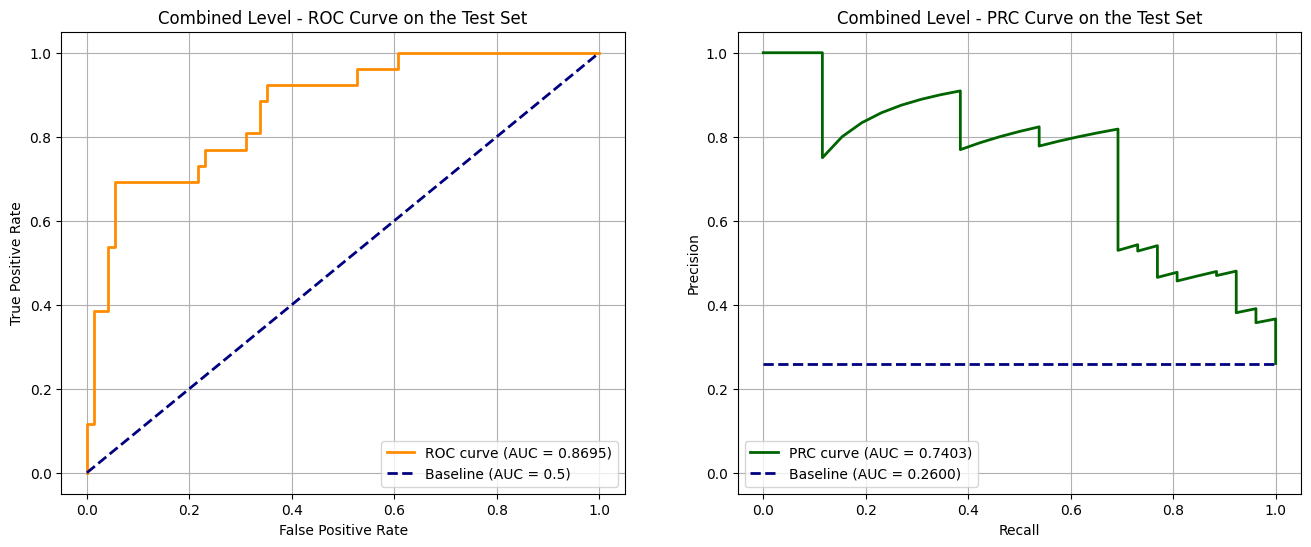

In [11]:
# Test With texture features
dataset_dir = 'DataBase/CRC_DX/test'
features_dir='SavedData/Features/CRC-DX/Test/CTransPath'
texture_features_dir='SavedData/Features/CRC-DX/Test/Textures'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

full_patient_map = build_patient_tile_map(dataset_dir)
dataSet = PrecomputedPatientCombinedFeatureDataset(
                                               features_dir=features_dir,
                                               texture_features_dir=texture_features_dir,
                                               patient_ids=list(full_patient_map.keys()))
dataLoader = DataLoader(dataSet, batch_size=1, shuffle=False, num_workers=4)

trf_path = 'SavedData/FinalModels/transformer/STAD/'
txt_path = 'SavedData/FinalModels/texture/STAD/'
print("Initializing Transformer model...")
model_trainer = Transformer_Model_Trainer(device,
                                          use_texture_features=True)
model_trainer.load('KFOld/20251104-111112_best_model_aggregator.pth')
model_trainer.load_texture('KFOld/20251104-111112_best_texture_model_texture_aggregator.pth')
model_trainer.evaluate_on_test_set(dataLoader)
model_trainer.load('KFOld/20251104-111806_best_model_aggregator.pth')
model_trainer.load_texture('KFOld/20251104-111806_best_texture_model_texture_aggregator.pth')
model_trainer.evaluate_on_test_set(dataLoader)
model_trainer.load('KFOld/20251104-112352_best_model_aggregator.pth')
model_trainer.load_texture('KFOld/20251104-112352_best_texture_model_texture_aggregator.pth')
model_trainer.evaluate_on_test_set(dataLoader)
model_trainer.load('KFOld/20251104-112924_best_model_aggregator.pth')
model_trainer.load_texture('KFOld/20251104-112924_best_texture_model_texture_aggregator.pth')
model_trainer.evaluate_on_test_set(dataLoader)
model_trainer.load('KFOld/20251104-113316_best_model_aggregator.pth')
model_trainer.load_texture('KFOld/20251104-113316_best_texture_model_texture_aggregator.pth')
model_trainer.evaluate_on_test_set(dataLoader)

In [ ]:
# Test Together
dataset_dir = 'DataBase/STAD/test'
features_dir='SavedData/Features/STAD/Test/CTransPath'
texture_features_dir='SavedData/Features/STAD/Test/Textures'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

full_patient_map = build_patient_tile_map(dataset_dir)
dataSet = PrecomputedPatientCombinedFeatureDataset(
                                               features_dir=features_dir,
                                               texture_features_dir=texture_features_dir,
                                               patient_ids=list(full_patient_map.keys()))
dataLoader = DataLoader(dataSet, batch_size=1, shuffle=False, num_workers=4)

aggregator_paths = [
    'SavedData/FinalModels/transformer/Combined/combined_transformer_1.pth',
    'SavedData/FinalModels/transformer/Combined/combined_transformer_2.pth',
    'SavedData/FinalModels/transformer/Combined/combined_transformer_3.pth',
    'SavedData/FinalModels/transformer/Combined/combined_transformer_4.pth',
    'SavedData/FinalModels/transformer/Combined/combined_transformer_5.pth'
]
texture_aggregator_paths = [
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_1.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_2.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_3.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_4.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_5.pth'
]

evalutate_models_together(aggregator_paths, texture_aggregator_paths, dataLoader)

Using device: cuda


c:\Users\Zsombor\Documents\Egyetem\Szakdoga\SzakdogaPythonEnvironment\transformer_model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  td = torch.load(r'SavedData/Save

KeyboardInterrupt: 

Using device: cuda


c:\Users\Zsombor\miniconda3\envs\msi_projekt\lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
c:\Users\Zsombor\Documents\Egyetem\Szakdoga\SzakdogaPythonEnvironment\transformer_model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allow

Aggregator weights loaded from SavedData/FinalModels/transformer/Combined/combined_transformer_1.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_1.pth
Using device: cuda


c:\Users\Zsombor\Documents\Egyetem\Szakdoga\SzakdogaPythonEnvironment\transformer_model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  td = torch.load(r'SavedData/Save

Aggregator weights loaded from SavedData/FinalModels/transformer/Combined/combined_transformer_2.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_2.pth
Using device: cuda


...

Aggregator weights loaded from SavedData/FinalModels/transformer/Combined/combined_transformer_3.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_3.pth
Using device: cuda


c:\Users\Zsombor\Documents\Egyetem\Szakdoga\SzakdogaPythonEnvironment\transformer_model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  td = torch.load(r'SavedData/Save

Aggregator weights loaded from SavedData/FinalModels/transformer/Combined/combined_transformer_4.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_4.pth
Using device: cuda


c:\Users\Zsombor\Documents\Egyetem\Szakdoga\SzakdogaPythonEnvironment\transformer_model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  td = torch.load(r'SavedData/Save

Aggregator weights loaded from SavedData/FinalModels/transformer/Combined/combined_transformer_5.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_5.pth
--- Model 1 Results: ---
Patient-level Metrics:
 ROC AUC: 0.9054
 PRC AUC: 0.8460
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8462, Specificity: 0.8514, Threshold: 0.4091169834136963
  Sensitivity: 0.8462, Specificity: 0.7027, Threshold: 0.40361231565475464
  Sensitivity: 0.8846, Specificity: 0.7027, Threshold: 0.4031572937965393
  Sensitivity: 0.8846, Specificity: 0.6486, Threshold: 0.4017748534679413
  Sensitivity: 0.9231, Specificity: 0.6486, Threshold: 0.4016404449939728
  Sensitivity: 0.9231, Specificity: 0.5000, Threshold: 0.3985273241996765
  Sensitivity: 0.9615, Specificity: 0.5000, Threshold: 0.39848023653030396
  Sensitivity: 0.9615, Specificity: 0.2297, Threshold: 0.38905030488967896
  Sensitivity: 1.0000, Specificity: 0.2297, Threshold: 0.3884989023

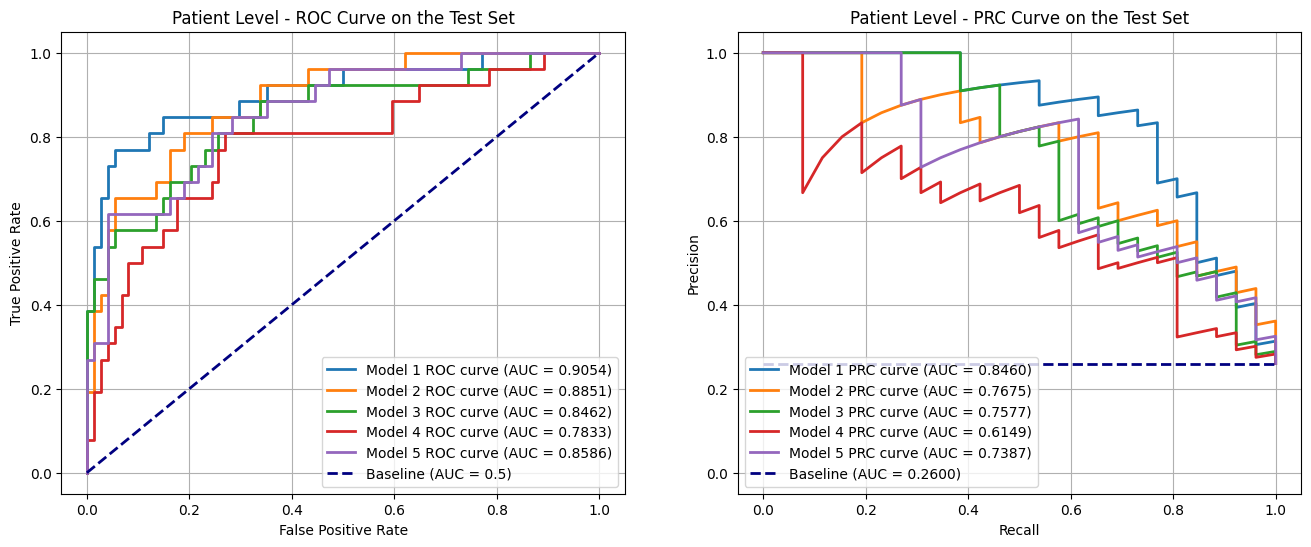

=== Summary of Texture-level results ===
Average ROC AUC: 0.5109 ± 0.0151
Average PRC AUC: 0.3231 ± 0.0392


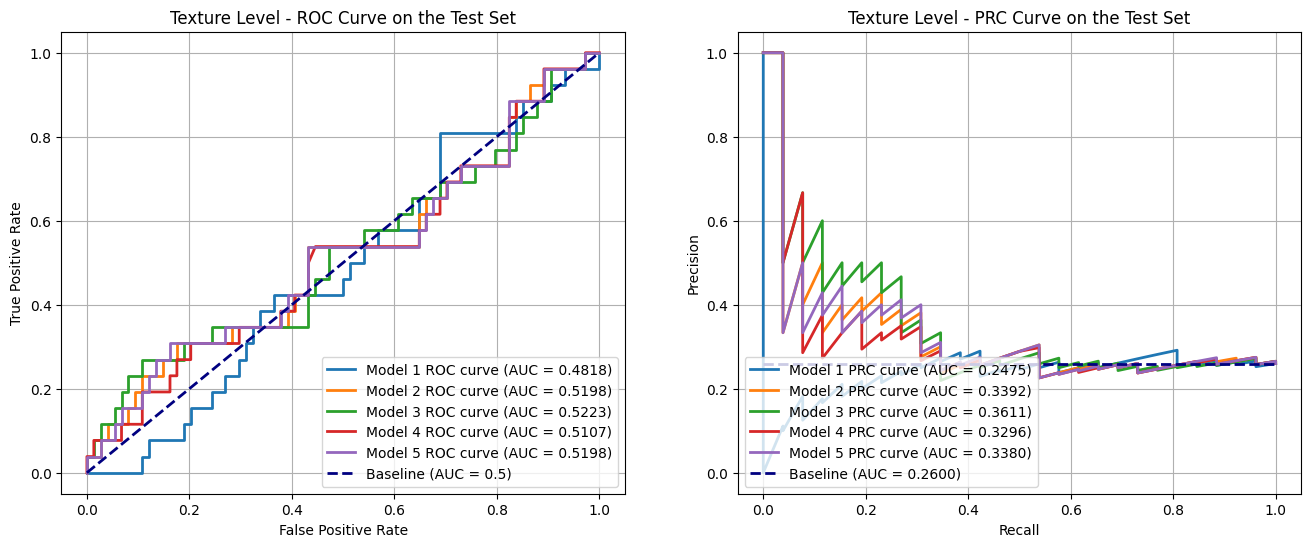

=== Summary of Combined-level results ===
Average ROC AUC: 0.8397 ± 0.0343
Average PRC AUC: 0.6819 ± 0.0969


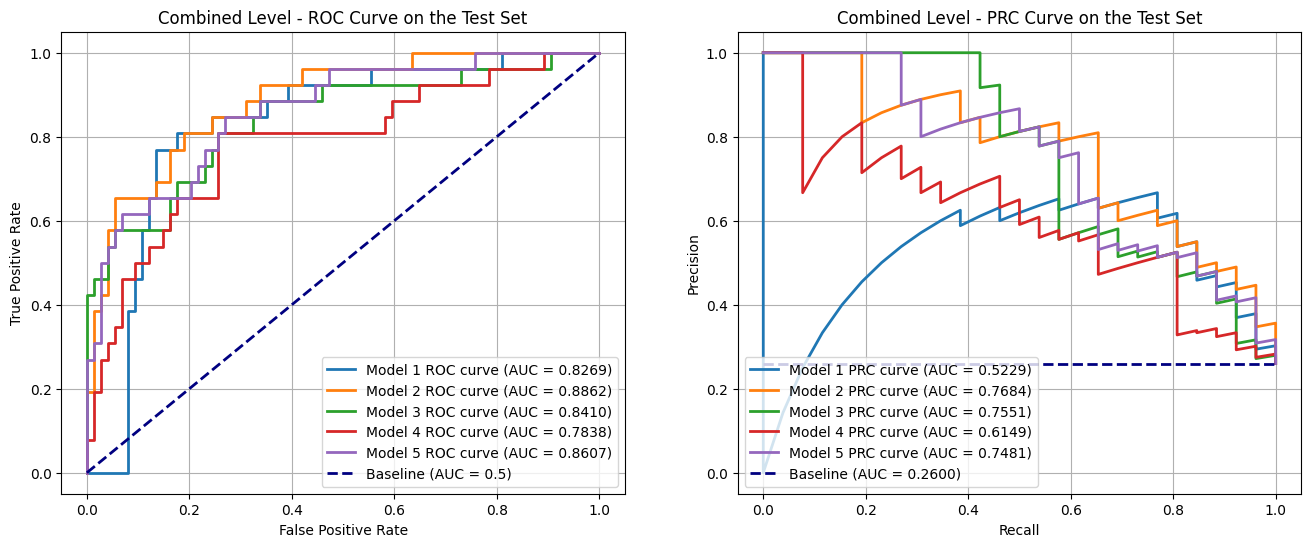

In [3]:
# Test Together
dataset_dir = 'DataBase/CRC_DX/test'
features_dir='SavedData/Features/CRC-DX/Test/CTransPath'
texture_features_dir='SavedData/Features/CRC-DX/Test/Textures'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

full_patient_map = build_patient_tile_map(dataset_dir)
dataSet = PrecomputedPatientCombinedFeatureDataset(
                                               features_dir=features_dir,
                                               texture_features_dir=texture_features_dir,
                                               patient_ids=list(full_patient_map.keys()))
dataLoader = DataLoader(dataSet, batch_size=1, shuffle=False, num_workers=4)

aggregator_paths = [
    'SavedData/FinalModels/transformer/Combined/combined_transformer_1.pth',
    'SavedData/FinalModels/transformer/Combined/combined_transformer_2.pth',
    'SavedData/FinalModels/transformer/Combined/combined_transformer_3.pth',
    'SavedData/FinalModels/transformer/Combined/combined_transformer_4.pth',
    'SavedData/FinalModels/transformer/Combined/combined_transformer_5.pth'
]
texture_aggregator_paths = [
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_1.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_2.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_3.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_4.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_5.pth'
]

evalutate_models_together(aggregator_paths, texture_aggregator_paths, dataLoader)

Using device: cuda


c:\Users\Zsombor\Documents\Egyetem\Szakdoga\SzakdogaPythonEnvironment\transformer_model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  td = torch.load(r'SavedData/Save

Aggregator weights loaded from SavedData/FinalModels/transformer/Combined/combined_transformer_1.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_1.pth
Using device: cuda


c:\Users\Zsombor\Documents\Egyetem\Szakdoga\SzakdogaPythonEnvironment\transformer_model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  td = torch.load(r'SavedData/Save

Aggregator weights loaded from SavedData/FinalModels/transformer/Combined/combined_transformer_2.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_2.pth
Using device: cuda


...

Aggregator weights loaded from SavedData/FinalModels/transformer/Combined/combined_transformer_3.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_3.pth
Using device: cuda


c:\Users\Zsombor\Documents\Egyetem\Szakdoga\SzakdogaPythonEnvironment\transformer_model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  td = torch.load(r'SavedData/Save

Aggregator weights loaded from SavedData/FinalModels/transformer/Combined/combined_transformer_4.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_4.pth
Using device: cuda


c:\Users\Zsombor\Documents\Egyetem\Szakdoga\SzakdogaPythonEnvironment\transformer_model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  td = torch.load(r'SavedData/Save

Aggregator weights loaded from SavedData/FinalModels/transformer/Combined/combined_transformer_5.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_5.pth
--- Model 1 Results: ---
Patient-level Metrics:
 ROC AUC: 0.8895
 PRC AUC: 0.7423
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8974, Specificity: 0.7195, Threshold: 0.4034123420715332
  Sensitivity: 0.8974, Specificity: 0.6471, Threshold: 0.4010661542415619
  Sensitivity: 0.9231, Specificity: 0.6471, Threshold: 0.40078240633010864
  Sensitivity: 0.9231, Specificity: 0.2896, Threshold: 0.39092978835105896
  Sensitivity: 0.9487, Specificity: 0.2896, Threshold: 0.3909204304218292
  Sensitivity: 0.9487, Specificity: 0.2534, Threshold: 0.390068382024765
  Sensitivity: 0.9744, Specificity: 0.2534, Threshold: 0.38978904485702515
  Sensitivity: 0.9744, Specificity: 0.1267, Threshold: 0.3859742283821106
  Sensitivity: 1.0000, Specificity: 0.1267, Threshold: 0.38565725088

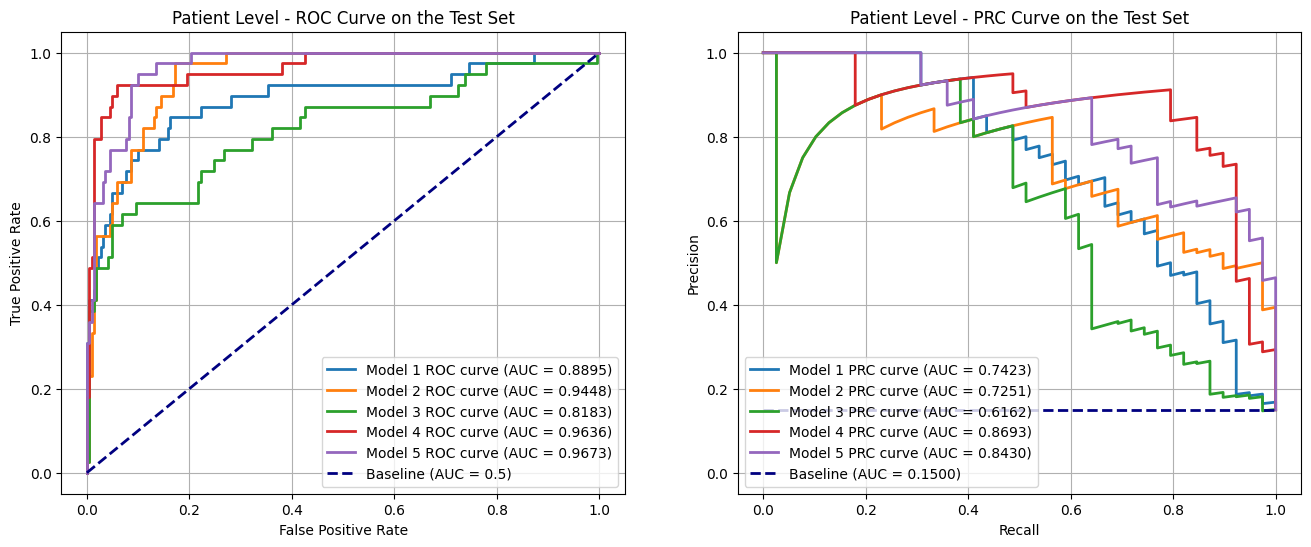

=== Summary of Texture-level results ===
Average ROC AUC: 0.9014 ± 0.0243
Average PRC AUC: 0.7280 ± 0.1460


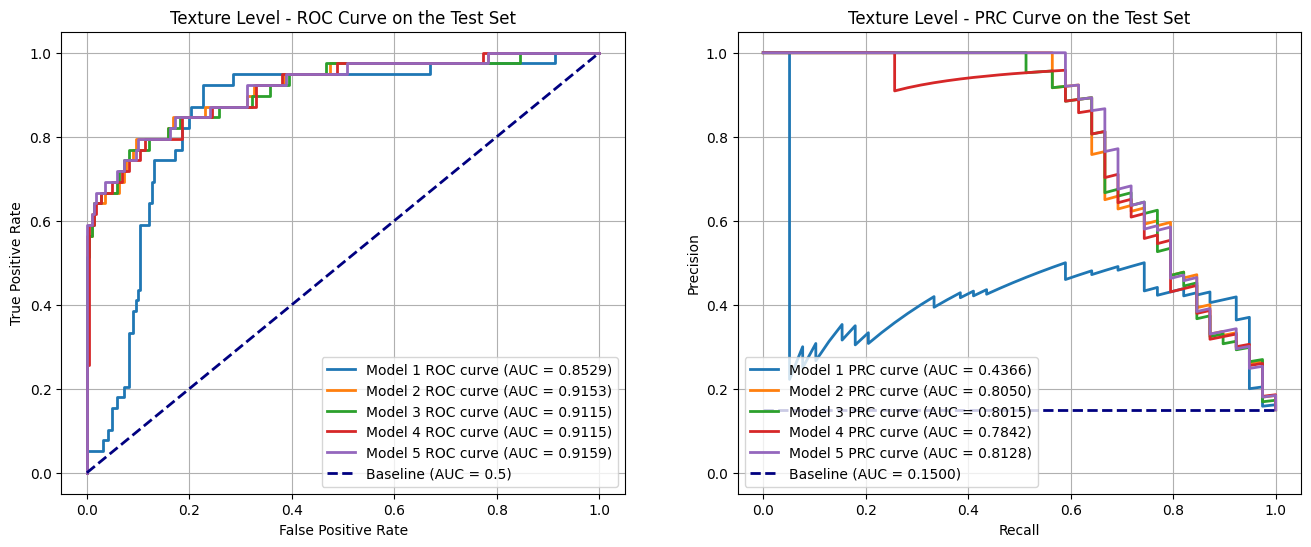

=== Summary of Combined-level results ===
Average ROC AUC: 0.9181 ± 0.0551
Average PRC AUC: 0.7326 ± 0.1396


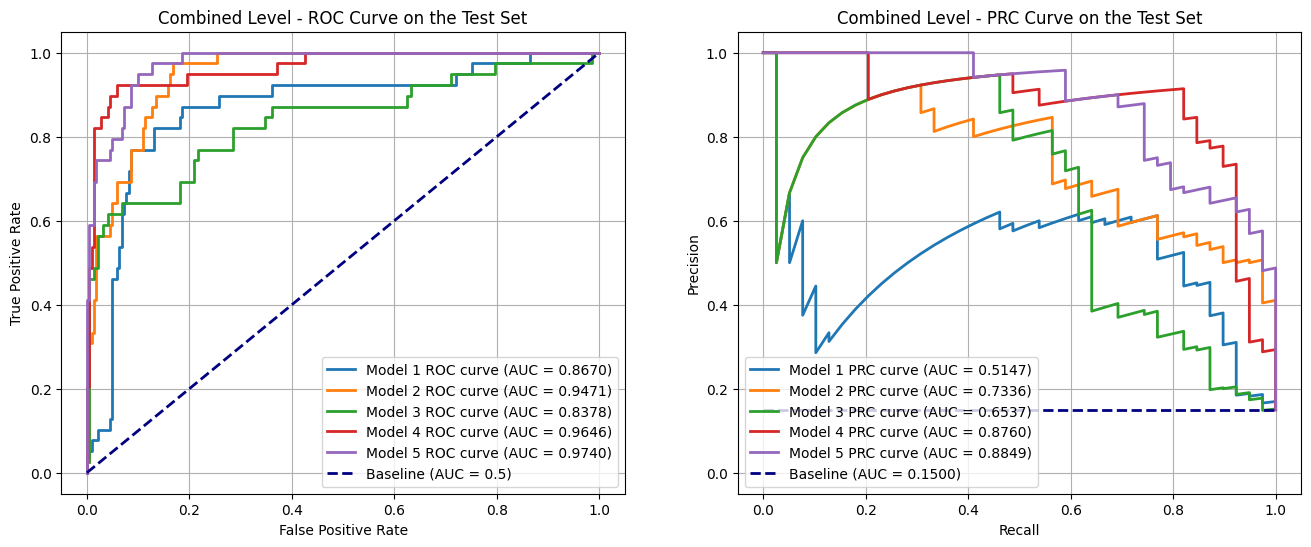

In [4]:
# Test Together
dataset_dir = 'DataBase/CRC_DX/train'
features_dir='SavedData/Features/CRC-DX/Train/CTransPath'
texture_features_dir='SavedData/Features/CRC-DX/Train/Textures'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

full_patient_map = build_patient_tile_map(dataset_dir)
dataSet = PrecomputedPatientCombinedFeatureDataset(
                                               features_dir=features_dir,
                                               texture_features_dir=texture_features_dir,
                                               patient_ids=list(full_patient_map.keys()))
dataLoader = DataLoader(dataSet, batch_size=1, shuffle=False, num_workers=4)

aggregator_paths = [
    'SavedData/FinalModels/transformer/Combined/combined_transformer_1.pth',
    'SavedData/FinalModels/transformer/Combined/combined_transformer_2.pth',
    'SavedData/FinalModels/transformer/Combined/combined_transformer_3.pth',
    'SavedData/FinalModels/transformer/Combined/combined_transformer_4.pth',
    'SavedData/FinalModels/transformer/Combined/combined_transformer_5.pth'
]
texture_aggregator_paths = [
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_1.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_2.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_3.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_4.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_5.pth'
]

evalutate_models_together(aggregator_paths, texture_aggregator_paths, dataLoader)

Using device: cuda


c:\Users\Zsombor\Documents\Egyetem\Szakdoga\SzakdogaPythonEnvironment\transformer_model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  td = torch.load(r'SavedData/Save

Aggregator weights loaded from 20251119-171132_best_model_aggregator.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_1.pth
Using device: cuda


c:\Users\Zsombor\Documents\Egyetem\Szakdoga\SzakdogaPythonEnvironment\transformer_model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  td = torch.load(r'SavedData/Save

Aggregator weights loaded from 20251119-172310_best_model_aggregator.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_2.pth
Using device: cuda


...

Aggregator weights loaded from 20251119-172912_best_model_aggregator.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_3.pth
Using device: cuda


c:\Users\Zsombor\Documents\Egyetem\Szakdoga\SzakdogaPythonEnvironment\transformer_model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  td = torch.load(r'SavedData/Save

Aggregator weights loaded from 20251119-173514_best_model_aggregator.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_4.pth
Using device: cuda


c:\Users\Zsombor\Documents\Egyetem\Szakdoga\SzakdogaPythonEnvironment\transformer_model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  td = torch.load(r'SavedData/Save

Aggregator weights loaded from 20251119-175022_best_model_aggregator.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_5.pth
--- Model 1 Results: ---
Patient-level Metrics:
 ROC AUC: 0.7661
 PRC AUC: 0.5623
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.9383, Specificity: 0.2996, Threshold: 0.3795802891254425
  Sensitivity: 0.9383, Specificity: 0.2863, Threshold: 0.3795725405216217
  Sensitivity: 0.9506, Specificity: 0.2863, Threshold: 0.37956589460372925
  Sensitivity: 0.9506, Specificity: 0.1938, Threshold: 0.3794685900211334
  Sensitivity: 0.9630, Specificity: 0.1938, Threshold: 0.37946486473083496
  Sensitivity: 0.9630, Specificity: 0.1145, Threshold: 0.37938958406448364
  Sensitivity: 0.9753, Specificity: 0.1145, Threshold: 0.37938207387924194
  Sensitivity: 0.9753, Specificity: 0.0925, Threshold: 0.37932682037353516
  Sensitivity: 1.0000, Specificity: 0.0925, Threshold: 0.37931808829307556
  Sensitivity: 1.0

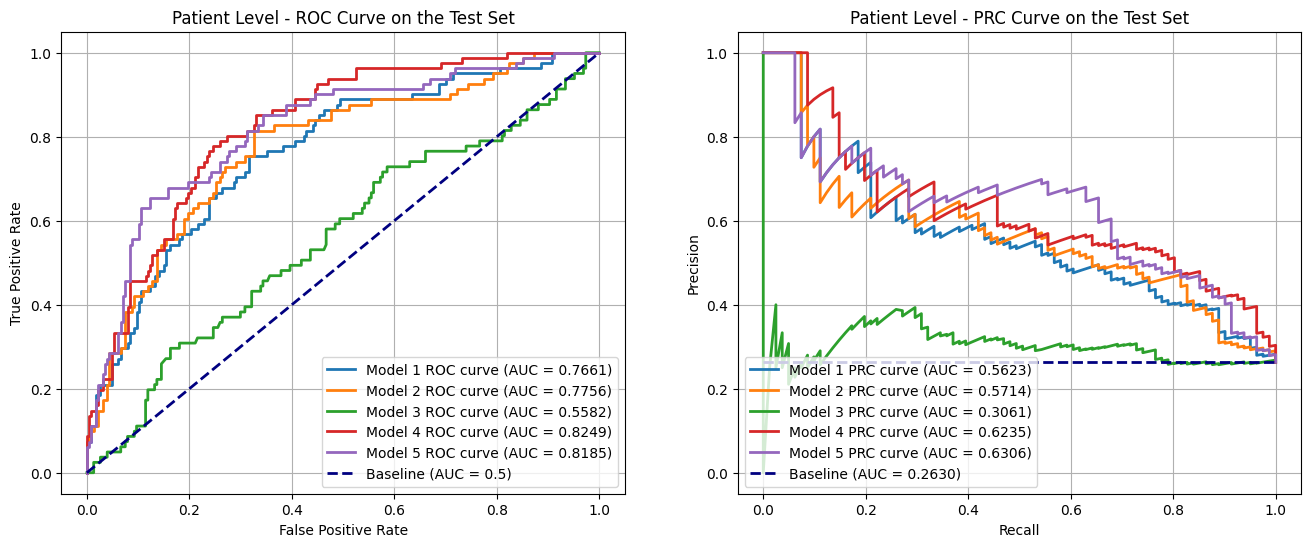

=== Summary of Texture-level results ===
Average ROC AUC: 0.4751 ± 0.0021
Average PRC AUC: 0.2721 ± 0.0072


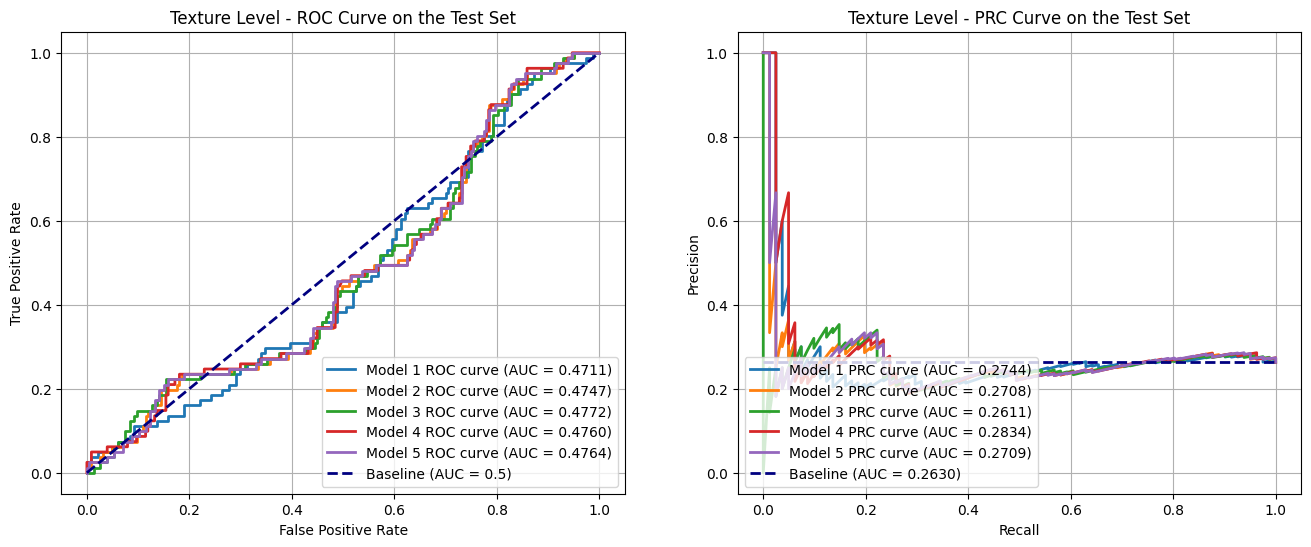

=== Summary of Combined-level results ===
Average ROC AUC: 0.6924 ± 0.1350
Average PRC AUC: 0.4765 ± 0.1482


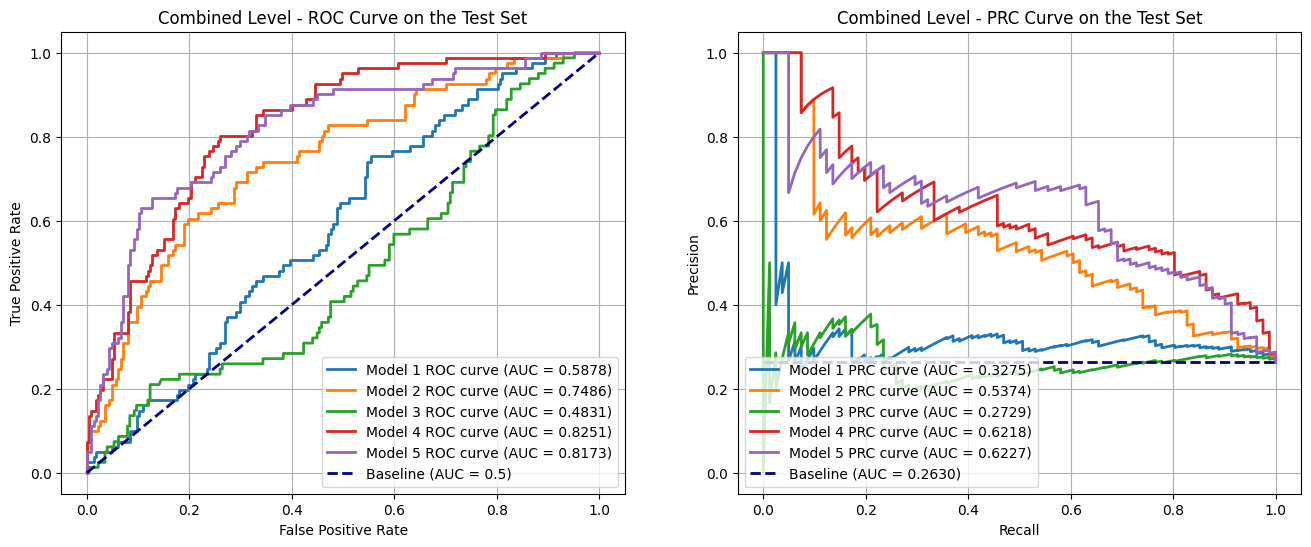

In [9]:
# Combined test
dataset_dir_1 = 'DataBase/CRC_DX/test'
features_dir_1='SavedData/Features/CRC-DX/Test/CTransPath'
texture_features_dir_1='SavedData/Features/CRC-DX/Test/Textures'

dataset_dir_2 = 'DataBase/CRC_KR/test'
features_dir_2='SavedData/Features/CRC-KR/Test/CTransPath'
texture_features_dir_2='SavedData/Features/CRC-KR/Test/Textures'

dataset_dir_3 = 'DataBase/STAD/test'
features_dir_3='SavedData/Features/STAD/Test/CTransPath'
texture_features_dir_3='SavedData/Features/STAD/Test/Textures'


full_patient_map_1 = build_patient_tile_map(dataset_dir_1)
dataSet_1 = PrecomputedPatientCombinedFeatureDataset(
                                        features_dir=features_dir_1,
                                        texture_features_dir=texture_features_dir_1,
                                        patient_ids=list(full_patient_map_1.keys()))
full_dataset = dataSet_1
all_targets = [full_patient_map_1[pid]['label'] for pid in full_patient_map_1.keys()]
if dataset_dir_2 is not None and features_dir_2 is not None:
    full_patient_map_2 = build_patient_tile_map(dataset_dir_2)
    dataSet_2 = PrecomputedPatientCombinedFeatureDataset(
                                            features_dir=features_dir_2,
                                            texture_features_dir=texture_features_dir_2,
                                            patient_ids=list(full_patient_map_2.keys()))
    full_dataset = torch.utils.data.ConcatDataset([full_dataset, dataSet_2])
    all_targets += [full_patient_map_2[pid]['label'] for pid in full_patient_map_2.keys()]
if dataset_dir_3 is not None and features_dir_3 is not None:
    full_patient_map_3 = build_patient_tile_map(dataset_dir_3)
    dataSet_3 = PrecomputedPatientCombinedFeatureDataset(
                                            features_dir=features_dir_3,
                                            texture_features_dir=texture_features_dir_3,
                                            patient_ids=list(full_patient_map_3.keys()))
    full_dataset = torch.utils.data.ConcatDataset([full_dataset, dataSet_3])
    all_targets += [full_patient_map_3[pid]['label'] for pid in full_patient_map_3.keys()]
dataLoader = DataLoader(full_dataset, batch_size=1, shuffle=False, num_workers=4)

aggregator_paths = [
    '20251119-171132_best_model_aggregator.pth',
    '20251119-172310_best_model_aggregator.pth',
    '20251119-172912_best_model_aggregator.pth',
    '20251119-173514_best_model_aggregator.pth',
    '20251119-175022_best_model_aggregator.pth'
]
texture_aggregator_paths = [
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_1.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_2.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_3.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_4.pth',
    'SavedData/FinalModels/texture/Combined/combined_texture_transformer_5.pth'
]

evalutate_models_together(aggregator_paths, texture_aggregator_paths, dataLoader)

Initializing Transformer model...


c:\Users\Zsombor\miniconda3\envs\msi_projekt\lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
c:\Users\Zsombor\Documents\Egyetem\Szakdoga\SzakdogaPythonEnvironment\transformer_model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allow

Aggregator weights loaded from SavedData/FinalModels/transformer/Combined/combined_transformer_1.pth
Texture aggregator weights loaded from SavedData/FinalModels/texture/Combined/combined_texture_transformer_1.pth

Starting evaluation on test set...

Test Set Patient-Level Metrics:

Patient-level Metrics:
 Accuracy: 81.08%
 Precision: 0.0000
 Recall: 0.0000
 Specificity: 1.0000
 F1-Score: 0.0000
 ROC AUC: 0.7210
 PRC AUC: 0.3870
 TP: 0, TN: 150, FP: 0, FN: 35

 Best F1 Score: 0.4923 at Threshold: 0.4249895215034485
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8857, Specificity: 0.3800, Threshold: 0.40515345335006714
  Sensitivity: 0.8857, Specificity: 0.3667, Threshold: 0.4050627052783966
  Sensitivity: 0.9143, Specificity: 0.3667, Threshold: 0.4050542116165161
  Sensitivity: 0.9143, Specificity: 0.3400, Threshold: 0.40397199988365173
  Sensitivity: 0.9429, Specificity: 0.3400, Threshold: 0.4038354754447937
  Sensitivity: 0.9429, Specificity: 0.2667, Threshold: 0.40130022

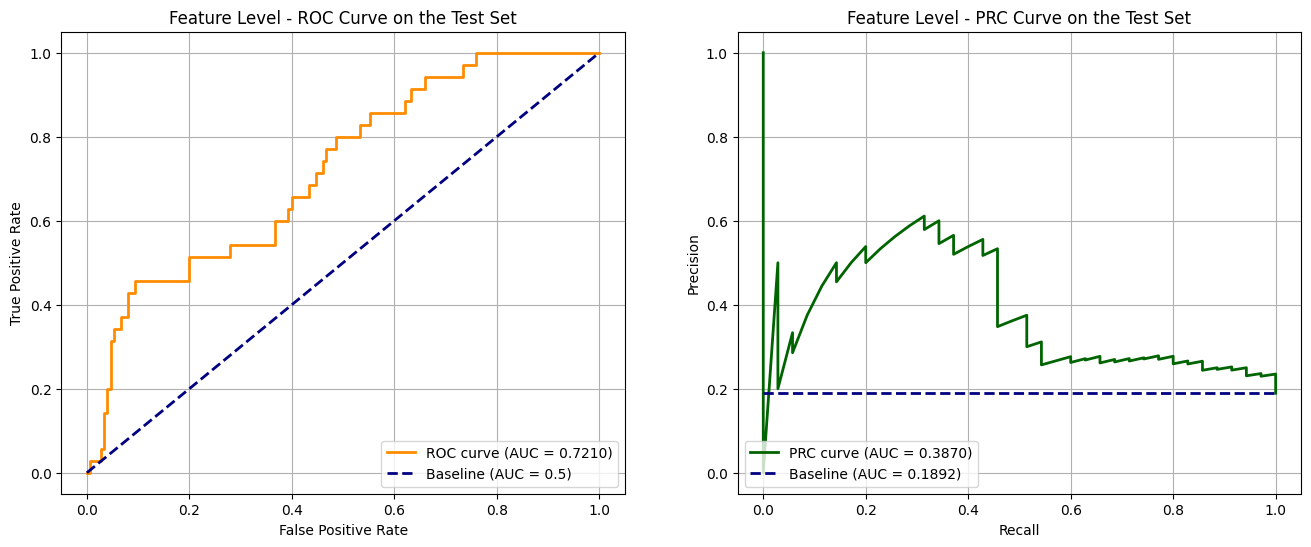


Texture Feature Aggregator Metrics:

Patient-level Metrics:
 Accuracy: 81.08%
 Precision: 0.0000
 Recall: 0.0000
 Specificity: 1.0000
 F1-Score: 0.0000
 ROC AUC: 0.8893
 PRC AUC: 0.6220
 TP: 0, TN: 150, FP: 0, FN: 35

 Best F1 Score: 0.7246 at Threshold: 0.14892813563346863
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.9143, Specificity: 0.6067, Threshold: 0.14841119945049286
  Sensitivity: 0.9143, Specificity: 0.5200, Threshold: 0.14836208522319794
  Sensitivity: 0.9429, Specificity: 0.5200, Threshold: 0.14835520088672638
  Sensitivity: 0.9429, Specificity: 0.5133, Threshold: 0.14835433661937714
  Sensitivity: 0.9714, Specificity: 0.5133, Threshold: 0.14835256338119507
  Sensitivity: 0.9714, Specificity: 0.4067, Threshold: 0.14829565584659576
  Sensitivity: 1.0000, Specificity: 0.4067, Threshold: 0.1482953280210495
  Sensitivity: 1.0000, Specificity: 0.2800, Threshold: 0.14824260771274567
  Sensitivity: 1.0000, Specificity: 0.2667, Threshold: 0.14824199676513672
  Sensit

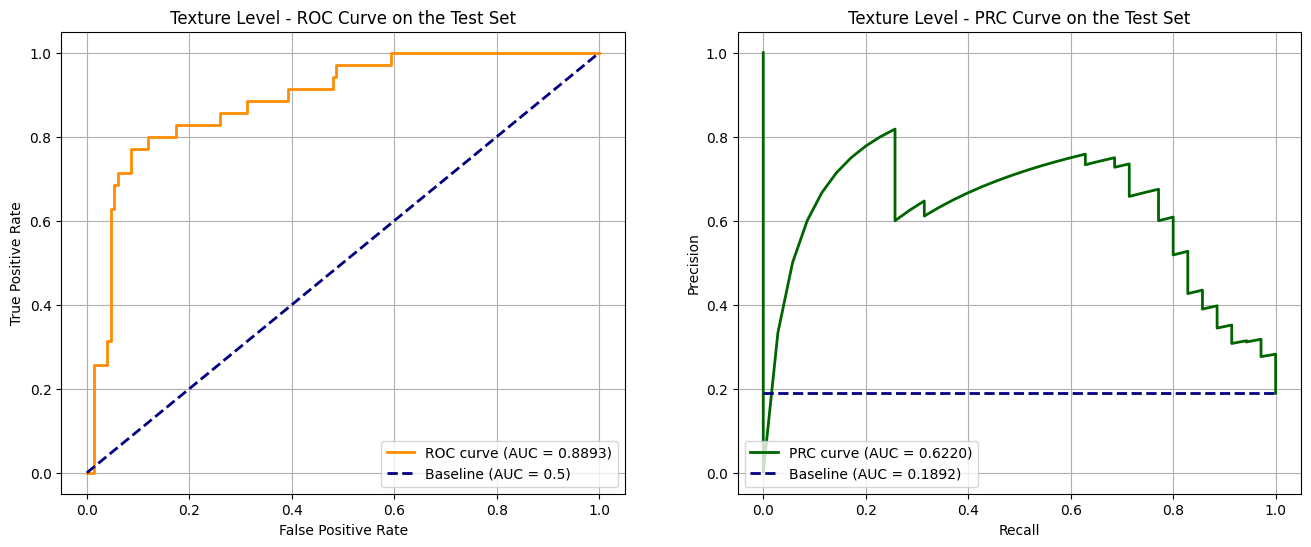


Combined Metrics:

Patient-level Metrics:
 Accuracy: 81.08%
 Precision: 0.0000
 Recall: 0.0000
 Specificity: 1.0000
 F1-Score: 0.0000
 ROC AUC: 0.7804
 PRC AUC: 0.5266
 TP: 0, TN: 150, FP: 0, FN: 35

 Best F1 Score: 0.5753 at Threshold: 0.26463234424591064
 Sensitivity/Specificity/Threshold pairs:
  Sensitivity: 0.8857, Specificity: 0.3733, Threshold: 0.25683411955833435
  Sensitivity: 0.8857, Specificity: 0.3600, Threshold: 0.2567268908023834
  Sensitivity: 0.9143, Specificity: 0.3600, Threshold: 0.2566344439983368
  Sensitivity: 0.9143, Specificity: 0.3400, Threshold: 0.2564014494419098
  Sensitivity: 0.9429, Specificity: 0.3400, Threshold: 0.25630712509155273
  Sensitivity: 0.9429, Specificity: 0.2667, Threshold: 0.2552364468574524
  Sensitivity: 0.9714, Specificity: 0.2667, Threshold: 0.2550215423107147
  Sensitivity: 0.9714, Specificity: 0.2333, Threshold: 0.2544306814670563
  Sensitivity: 1.0000, Specificity: 0.2333, Threshold: 0.2543030381202698
  Sensitivity: 1.0000, Specifici

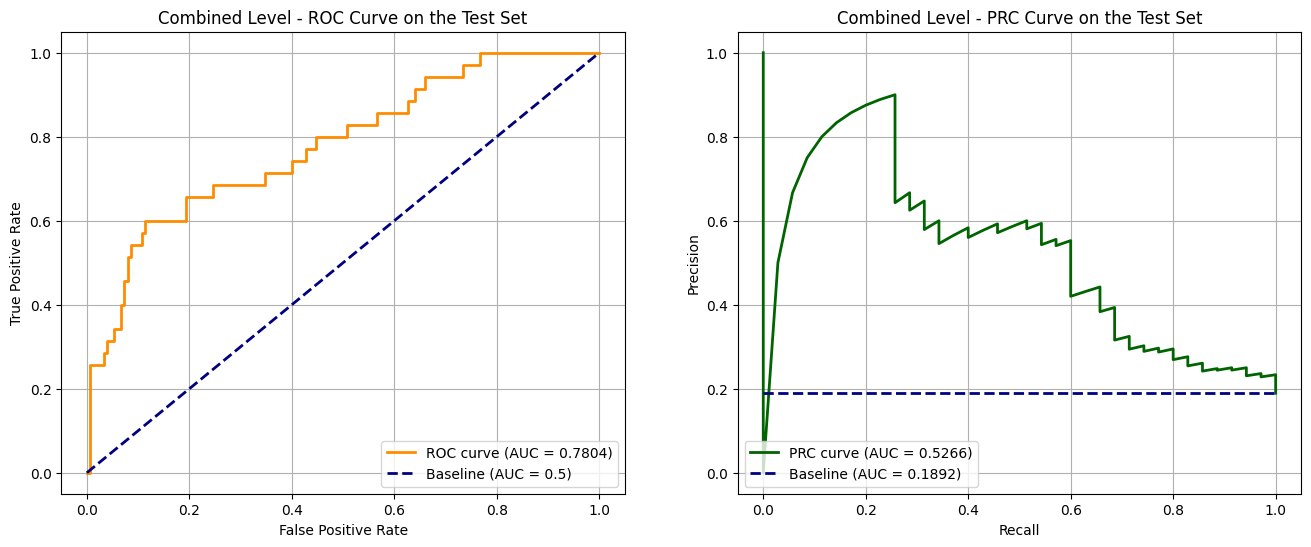

In [4]:
# Test With texture features
dataset_dir = 'DataBase/STAD/train'
features_dir='SavedData/Features/STAD/Train/CTransPath'
texture_features_dir='SavedData/Features/STAD/Train/Textures'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

full_patient_map = build_patient_tile_map(dataset_dir)
dataSet = PrecomputedPatientCombinedFeatureDataset(
                                               features_dir=features_dir,
                                               texture_features_dir=texture_features_dir,
                                               patient_ids=list(full_patient_map.keys()))
dataLoader = DataLoader(dataSet, batch_size=1, shuffle=False, num_workers=4)

trf_path = 'SavedData/FinalModels/transformer/STAD/'
txt_path = 'SavedData/FinalModels/texture/STAD/'
print("Initializing Transformer model...")
model_trainer = Transformer_Model_Trainer(device,
                                          use_texture_features=True)
model_trainer.load('SavedData/FinalModels/transformer/Combined/combined_transformer_1.pth')
model_trainer.load_texture('SavedData/FinalModels/texture/Combined/combined_texture_transformer_1.pth')
model_trainer.evaluate_on_test_set(dataLoader)